# Actividad 1 · Pipeline de scikit-learn

**Link al repo:** https://github.com/DiegoLinares11/Actividad1-MLOPS 

## Integrantes:
#### Diego Linares · Andy Fuentes · Christian Echeverria · Diederich Solis



**Dataset:** `champions_league_matches.csv` — el mismo que analizamos en el Ejercicio 1.

En el Ejercicio 1 hicimos el análisis exploratorio del dataset y propusimos un modelo:
*predecir el resultado del partido (clasificación multiclase)*. Esta actividad es la continuación:
construimos el pipeline de preparación de datos para ese modelo y mostramos su diagrama.

Todo el desarrollo se enmarca en las dos primeras etapas de **CRISP-DM**.

## 1. Business Understanding (Comprensión del negocio)

Queremos **anticipar el resultado de un partido de Champions League** a partir de las estadísticas
de juego (posesión, tiros a puerta, atajadas).

- **Objetivo:** clasificar cada partido como `Home Win`, `Away Win` o `Draw`.
- **Para qué sirve:** análisis deportivo, previas de partidos, apoyo a decisiones tácticas.
- **Criterio de éxito:** superar la clase mayoritaria (el local gana ~49% de los partidos) y que el
  pipeline sea reproducible por todo el equipo en cualquier computadora.

## 2. Data Understanding (Comprensión de los datos)

Del análisis del Ejercicio 1 ya sabemos lo siguiente, y es justo lo que el pipeline tiene que resolver:

| Hallazgo del Ejercicio 1 | Cómo lo atiende el pipeline |
|---|---|
| El CSV trae **7 filas totalmente vacías** que separan jornadas | Se eliminan en el filtrado (quedan 144 partidos) |
| La posesión viene como texto `'63%'` | Transformador `PorcentajeATexto` |
| Tiros y atajadas vienen como texto `'3 of 10'` | Transformador `RatioATexto` (genera *hechos* e *intentos*) |
| `home_saves_pct` tiene algunos nulos (casos de 0 de 0) | Imputación por mediana |
| Los equipos son variables categóricas | One-Hot Encoding |

**Ojo con la fuga de información (*data leakage*):** las columnas `score` y `winner` **revelan el
resultado**. Si las dejáramos como variables de entrada, el modelo tendría 100% de acierto pero sería
inútil en un partido que aún no termina. Por eso se descartan en el filtrado.

**Variable objetivo:** `result` (Home Win: 71, Away Win: 48, Draw: 25).

In [ ]:
from sklearn import set_config

# Hace que los estimadores se muestren como DIAGRAMA (no como texto)
set_config(display="diagram")

from act1_pipeline import (
    extraer_datos, filtrar_datos, separar_datos, construir_pipeline,
    NUMERIC_FEATURES, PERCENT_FEATURES, RATIO_FEATURES, CATEGORICAL_FEATURES,
    LEAKAGE_COLUMNS, TARGET,
)

### Etapa 1 — Extracción
Se carga el CSV de partidos que viene empaquetado dentro de la librería.

In [ ]:
df = extraer_datos()
print("Forma del CSV crudo:", df.shape)
df.head()

Forma del CSV crudo: (151, 18)


,date,home_team,away_team,score,venue,referee,home_possession,away_possession,home_shots_on_target,away_shots_on_target,home_saves,away_saves,home_shots_on_target_pct,away_shots_on_target_pct,home_saves_pct,away_saves_pct,result,winner
0,2025-09-16,PSV,Union SG,1–3,Philips Stadion,Anthony Taylor,63%,37%,3 of 10,8 of 18,4 of 8,2 of 3,30.0,44.4,50.0,66.7,Away Win,Union SG
1,2025-09-16,Athletic Club,Arsenal,0–2,San Mamés,Donatas Rumšas,38%,62%,2 of 11,6 of 11,4 of 6,2 of 2,18.2,54.5,66.7,100.0,Away Win,Arsenal
2,2025-09-16,Tottenham Hotspur,Villarreal,1–0,Tottenham Hotspur Stadium,Rade Obrenović,58%,42%,1 of 9,0 of 10,0 of 0,1 of 1,11.1,0.0,NaN,100.0,Home Win,Tottenham Hotspur
3,2025-09-16,Benfica,Qarabağ,2–3,Estádio do Sport Lisboa e Benfica,Erik Lambrechts,53%,47%,3 of 14,5 of 10,2 of 5,1 of 3,21.4,50.0,40.0,33.3,Away Win,Qarabağ
4,2025-09-16,Juventus,Dortmund,4–4,Allianz Stadium,François Letexier,52%,48%,7 of 19,5 of 10,1 of 5,3 of 7,36.8,50.0,20.0,42.9,Draw,Draw


In [ ]:
# Se confirman los dos problemas detectados en el Ejercicio 1
print("Filas totalmente vacías:", int(df.isna().all(axis=1).sum()))
print("\nColumnas numéricas guardadas como texto:")
df[["home_possession", "home_shots_on_target", "home_saves"]].head(3)

Filas totalmente vacías: 7

Columnas numéricas guardadas como texto:


,home_possession,home_shots_on_target,home_saves
0,63%,3 of 10,4 of 8
1,38%,2 of 11,4 of 6
2,58%,1 of 9,0 of 0


### Etapa 2 — Filtrado
Se eliminan las filas vacías, las columnas que revelan el resultado (`score`, `winner`) y las que no
aportan al modelo (`date`, `venue`, `referee`).

In [ ]:
df_filtrado = filtrar_datos(df)

print("Antes:  ", df.shape)
print("Después:", df_filtrado.shape)
print("\nColumnas descartadas por fuga de información:", LEAKAGE_COLUMNS)
print("\nDistribución de la variable objetivo:")
print(df_filtrado[TARGET].value_counts())

Antes:   (151, 18)
Después: (144, 13)

Columnas descartadas por fuga de información: ['score', 'winner']

Distribución de la variable objetivo:
result
Home Win    71
Away Win    48
Draw        25
Name: count, dtype: int64


### Etapa 4 — Separación del dataset
Se divide en `X`/`y` y en entrenamiento y prueba, **estratificando** por `result` para que las tres
clases queden representadas en ambos conjuntos (importante porque `Draw` es la clase minoritaria).

In [ ]:
X_train, X_test, y_train, y_test = separar_datos(df_filtrado)
print("train:", X_train.shape, "  test:", X_test.shape)
print("\nProporción de clases en train:")
print(y_train.value_counts(normalize=True).round(3))

train: (115, 12)   test: (29, 12)

Proporción de clases en train:
result
Home Win    0.496
Away Win    0.330
Draw        0.174
Name: proportion, dtype: float64


### Etapa 3 — Manejo de los diferentes tipos de variables

Este dataset tiene **cuatro tipos** de variables y cada uno necesita un tratamiento distinto:

| Tipo | Columnas | Tratamiento |
|---|---|---|
| Numéricas ya limpias | `*_pct` | imputar (mediana) → estandarizar |
| Porcentaje en texto | `home_possession`, `away_possession` | `'63%'` → `63.0` → imputar → estandarizar |
| Razón en texto | `*_shots_on_target`, `*_saves` | `'3 of 10'` → `3.0` y `10.0` → imputar → estandarizar |
| Categóricas | `home_team`, `away_team` | imputar (moda) → One-Hot Encoding |

In [ ]:
print("Numéricas:  ", NUMERIC_FEATURES)
print("Porcentajes:", PERCENT_FEATURES)
print("Razones:    ", RATIO_FEATURES)
print("Categóricas:", CATEGORICAL_FEATURES)

Numéricas:   ['home_shots_on_target_pct', 'away_shots_on_target_pct', 'home_saves_pct', 'away_saves_pct']
Porcentajes: ['home_possession', 'away_possession']
Razones:     ['home_shots_on_target', 'away_shots_on_target', 'home_saves', 'away_saves']
Categóricas: ['home_team', 'away_team']


## Diagrama del pipeline

Al ejecutar la siguiente celda, scikit-learn genera el **diagrama interactivo** del pipeline.
Se puede hacer clic en cada bloque para desplegar sus parámetros.

In [ ]:
pipe = construir_pipeline()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('porcentajes', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

### Entrenamiento y evaluación
Se entrena el pipeline completo (preprocesamiento + modelo) y se evalúa en el conjunto de prueba.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print()
print(classification_report(y_test, y_pred, digits=3))

Accuracy: 0.724

              precision    recall  f1-score   support

    Away Win      0.615     0.800     0.696        10
        Draw      0.500     0.200     0.286         5
    Home Win      0.857     0.857     0.857        14

    accuracy                          0.724        29
   macro avg      0.658     0.619     0.613        29
weighted avg      0.712     0.724     0.703        29



In [ ]:
# El pipeline ya entrenado también se muestra como diagrama (marcado como "Fitted")
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('porcentajes', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

Captura de evidencia

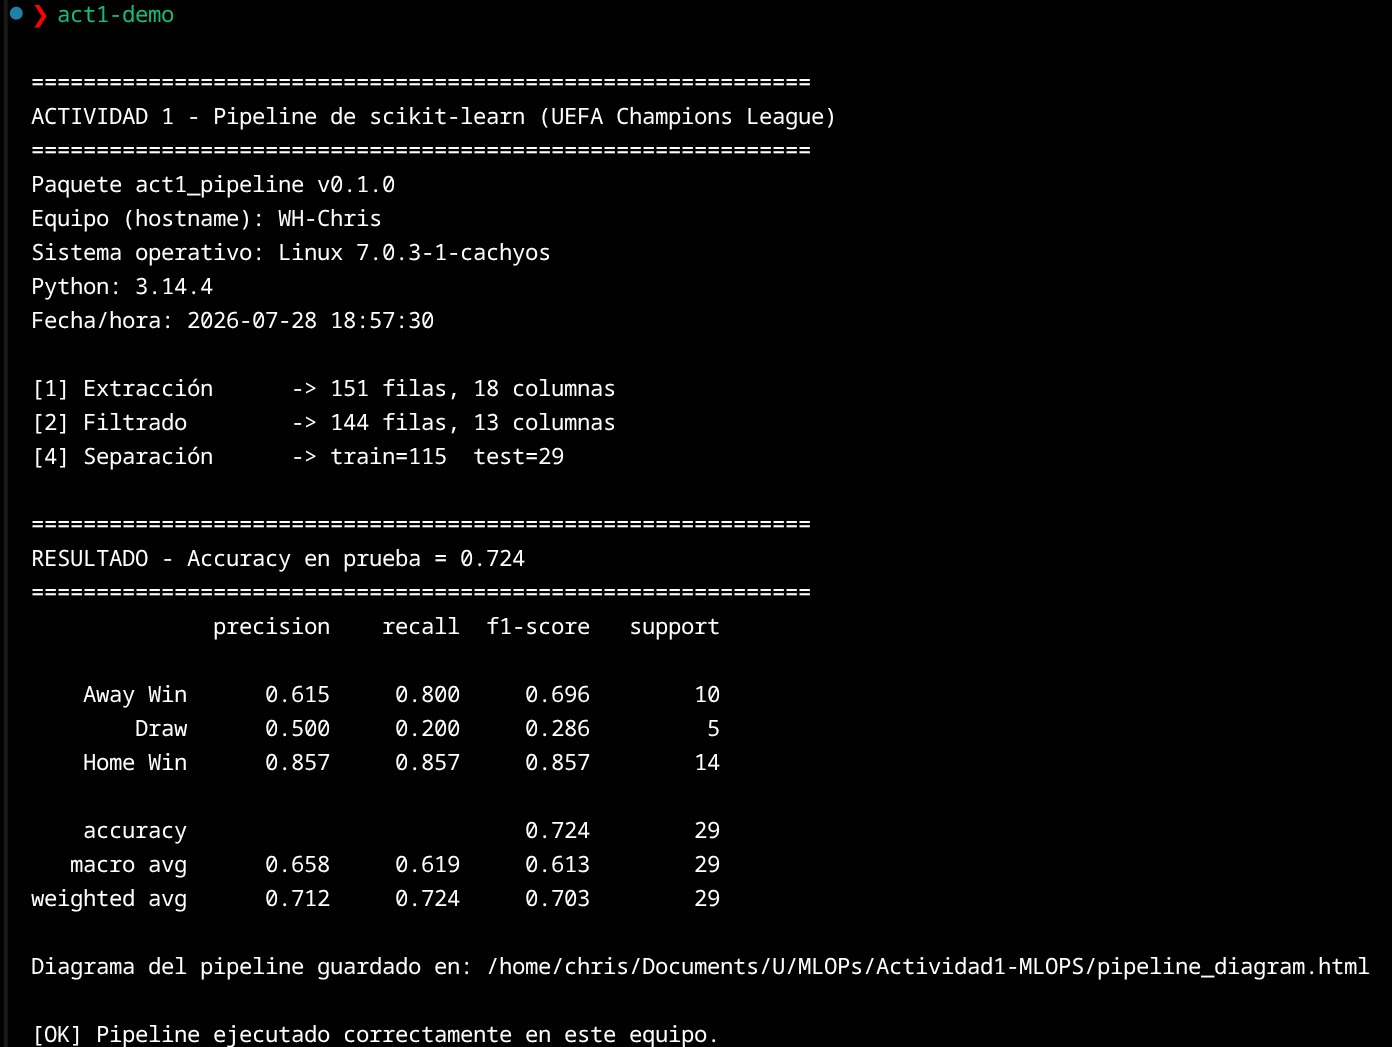

Mi compu, diferentes SO y todo y da mismo resultado:


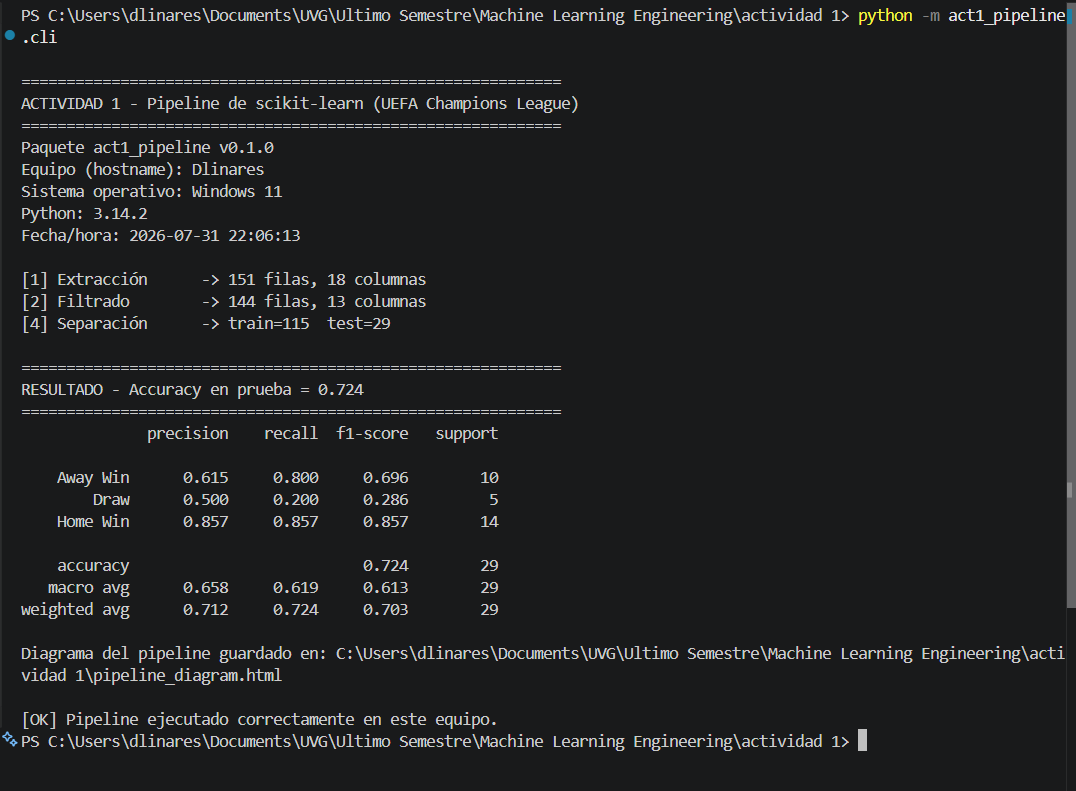